#### 1. Find Largest correlations in California housing dataset

- Look through the table manually and see if you can find the most negative and most positive correlations.
- Try to automate that search using Python code.
  - Hint: To find the minimum, use the `min()` and `idxmin()` methods. 
  To find the maximum, hide the diagonals first using `corr.replace(1.0, np.nan)`

In [1]:
from pandas import DataFrame

from sklearn.datasets import fetch_california_housing

housing_data = fetch_california_housing()
housing = DataFrame(housing_data.data, columns=housing_data.feature_names)

In [2]:
corr = housing.corr()

corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


In [3]:
corr.min()

MedInc       -0.119034
HouseAge     -0.296244
AveRooms     -0.153277
AveBedrms    -0.077747
Population   -0.296244
AveOccup     -0.006181
Latitude     -0.924664
Longitude    -0.924664
dtype: float64

In [4]:
corr.min().idxmin()

'Latitude'

In [5]:
corr[corr.min().idxmin()].idxmin()

'Longitude'

In [6]:
corr.min().idxmin(), corr[corr.min().idxmin()].idxmin()

('Latitude', 'Longitude')

In [7]:
corr.min().min()

-0.9246644339150366

In [8]:
import numpy as np

In [9]:
new_corr = corr.replace(1.0, np.nan)

new_corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,NaN,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,NaN,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,NaN,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,NaN,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,NaN,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,NaN,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,NaN,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,NaN


In [11]:
new_corr.max().idxmax(), new_corr[new_corr.max().idxmax()].idxmax()

('AveRooms', 'AveBedrms')

In [12]:
new_corr.max().max()

0.8476213257130424

#### 2. Iris correlation

Calculate correlation matrix and scatter matrix using the iris dataset.

You can find them listed at https://scikit-learn.org/stable/datasets/toy_dataset.html. 

_Iris_ is a classic dataset used in machine learning which it is worth being aware of.

In [13]:
from sklearn.datasets import load_iris

iris, iris_target = load_iris(as_frame=True, return_X_y=True)
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [14]:
iris_corr = iris.corr()

<Axes: >

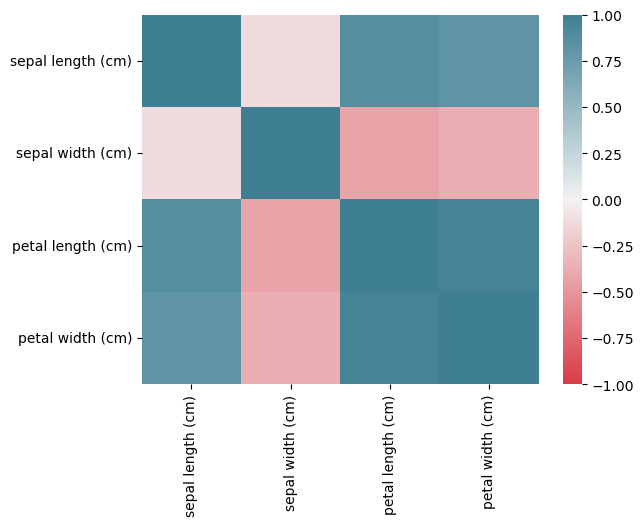

In [15]:
import seaborn as sns

cmap = sns.diverging_palette(10, 220, as_cmap=True)
sns.heatmap(iris_corr, vmin=-1, vmax=1, cmap=cmap)



In [16]:
from pandas.plotting import scatter_matrix

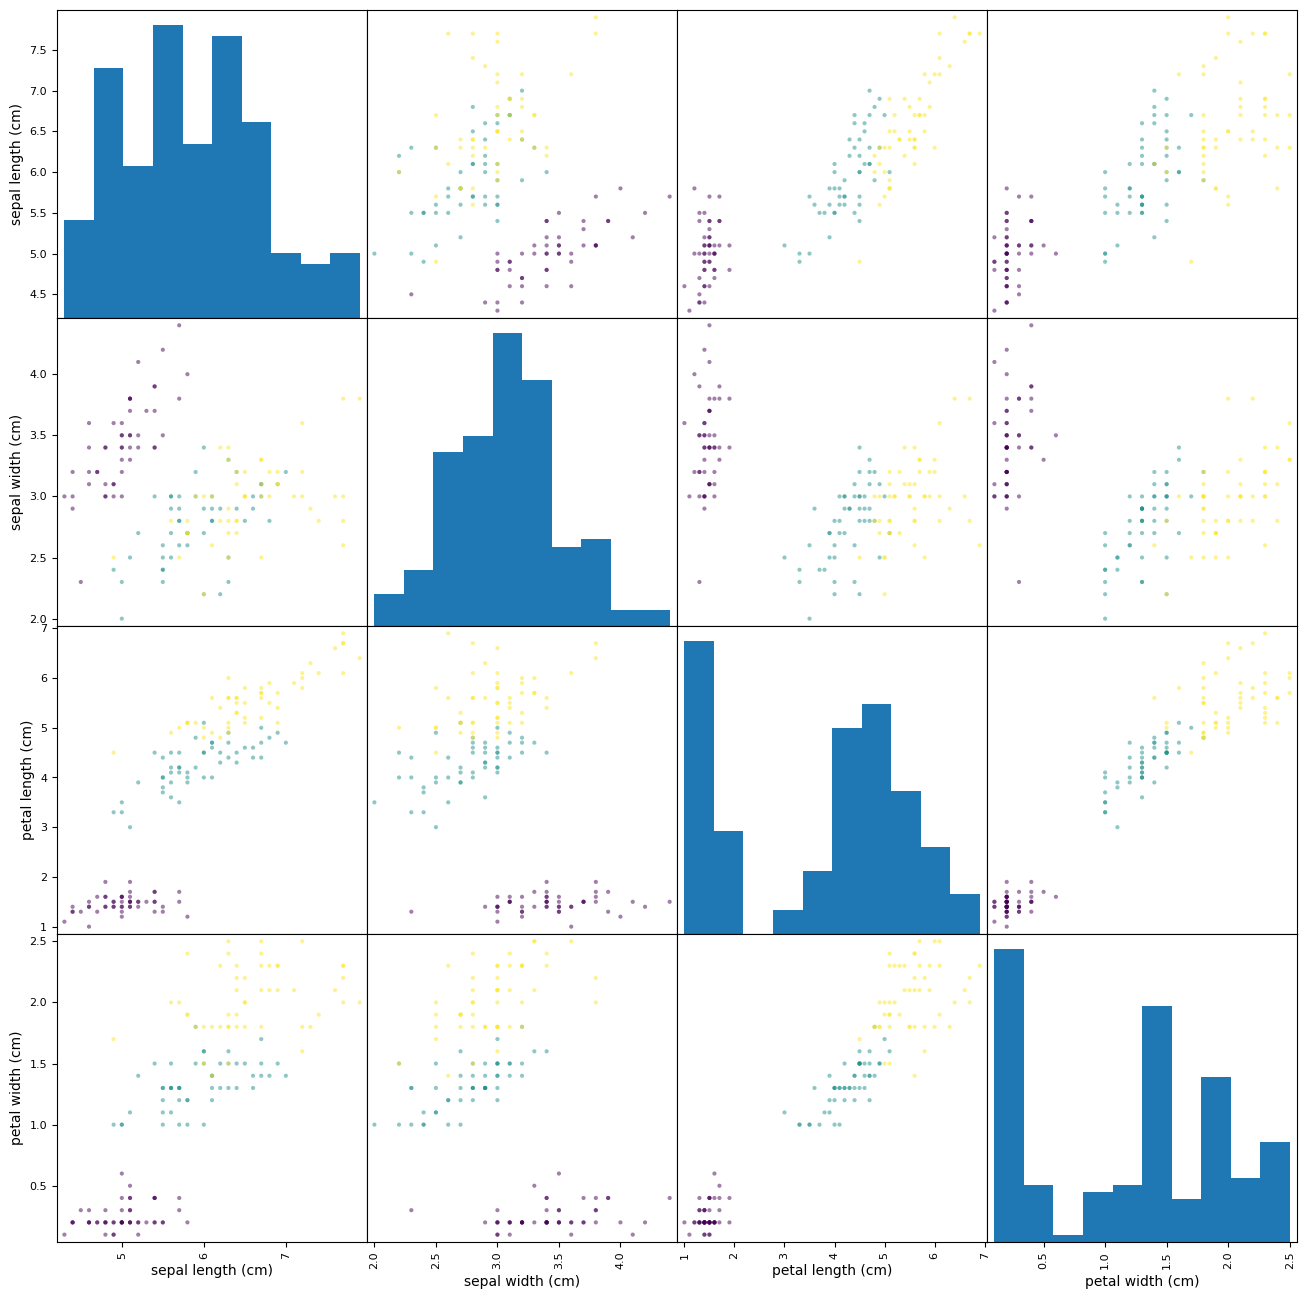

In [17]:
a = scatter_matrix(iris, figsize=(16,16), c=iris_target)

#### 3. Linear regression diabetes dataset

- Load the [diabetes dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) from the scikit-learn collection. You can load the dataset into pandas with:
  ```python
  from sklearn.datasets import load_diabetes
  
  X, y = load_diabetes(as_frame=True, return_X_y=True)
  ```
- Split the data into `train` and `test` subsets
- Fit and plot the linear relationship between the "bmi" column (Body mass index) and the "target" column (quantitative measure of disease progression one year after baseline). 
- Calculate the score of the model against the `test` data set. 

In [18]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

In [20]:
X, y = load_diabetes(as_frame=True, return_X_y=True)

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = LinearRegression(fit_intercept=True)

In [22]:
model.fit(X_train[['bmi']], y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
model.score(X_test[['bmi']], y_test)

0.3172099449537781

In [27]:
import pandas as pd

In [28]:
x_fit = pd.DataFrame({'bmi':[X['bmi'].min(), X['bmi'].max()]})
y_pred = model.predict(x_fit)

In [30]:
import matplotlib.pyplot as plt

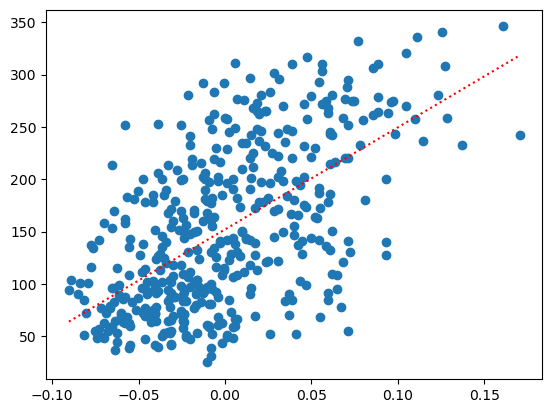

In [31]:
fig, ax = plt.subplots()

ax.scatter(X['bmi'], y)
ax.plot(x_fit['bmi'], y_pred, linestyle=':', color='red')